# 04 - Pitch Type Frequency

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook conducts **Layer 1** of a three-layer analytical framework — examining whether certain pitch types are thrown at meaningfully different rates across MLB ballparks.

Pitch type proportions are computed per park and compared against the league-wide baseline established in `02_eda.ipynb` (Fastball 55.85%, Breaking 29.83%, Offspeed 14.32%). Deviations from that baseline are signal of interest here.

No contact quality or swing outcome data is used in this notebook — only pitch type composition. Outcome and quality layers follow in notebooks 5 and 6.

*Sample*: 173,137 swings across 29 parks (2023–2025 pooled)
<br>
*Granularity*: Park-level pitch type proportions (Level 1 classification of FB, BB, Offspead)
<br>
*Baseline*: League-wide pitch type frequencies from EDA

___
## 1) Setup & Data Load

In [2]:
# Setup

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Database connection 
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

# Color scheme (project-wide)
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

In [3]:
# Quick Validation

n_rows  = len(df)
n_parks = df["home_team"].nunique()
parks   = sorted(df["home_team"].unique())

print(f"Rows loaded:  {n_rows:,}")
print(f"Parks loaded: {n_parks}")
print(f"\nParks ({n_parks}):\n{parks}")

# surface any unexpected pitch_category values early
print(f"\nPitch categories present:\n{df['pitch_category'].value_counts()}")

Rows loaded:  173,137
Parks loaded: 29

Parks (29):
['ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']

Pitch categories present:
pitch_category
Fastball    96689
Breaking    51650
Offspeed    24798
Name: count, dtype: int64


___
## 2) League-Wide Baseline (Reference Point)

In [4]:
# recompute from sample rather than hard-coding

league_counts = df["pitch_category"].value_counts()
league_props  = df["pitch_category"].value_counts(normalize=True)

league_baseline = pd.DataFrame({
    "n":          league_counts,
    "proportion": league_props,
    "pct":        league_props * 100,
}).loc[["Fastball", "Breaking", "Offspeed"]] 

print(f"League-Wide Baseline  (n = {len(df):,})\n")
print(league_baseline.to_string())

League-Wide Baseline  (n = 173,137)

                    n  proportion        pct
pitch_category                              
Fastball        96689    0.558454  55.845371
Breaking        51650    0.298319  29.831867
Offspeed        24798    0.143228  14.322762


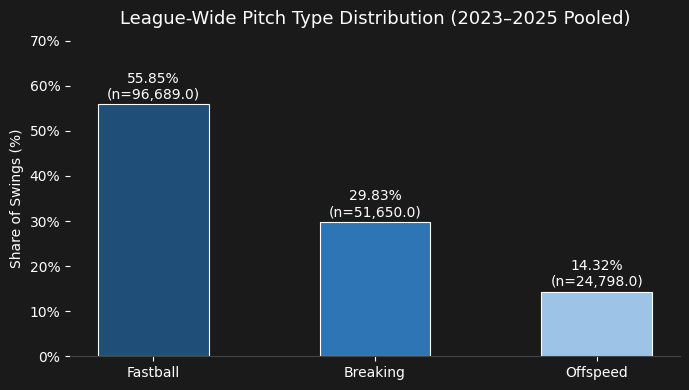

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    league_baseline.index,
    league_baseline["pct"],
    color=[COLORS[c] for c in league_baseline.index],
    width=0.5,
    edgecolor="white",
    linewidth=0.8,
)

# label each bar with percentage
for i, (cat, row) in enumerate(league_baseline.iterrows()):
    ax.text(
        i, row["pct"] + 0.5,
        f"{row['pct']:.2f}%\n(n={row['n']:,})",
        ha="center", va="bottom",
        fontsize=10, color="white"
    )

ax.set_title("League-Wide Pitch Type Distribution (2023–2025 Pooled)", 
             fontsize=13, pad=12, color="white")
ax.set_ylabel("Share of Swings (%)", color="white")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 70)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#444444")

plt.tight_layout()
plt.show()

___
## 3) Park-Level Pitch Type Proportions (Level 1)

In [6]:
# count swings per park per pitch category, then normalize within each park
park_counts = (
    df.groupby(["home_team", "pitch_category"])
    .size()
    .unstack(fill_value=0)
    [["Fastball", "Breaking", "Offspeed"]]  # enforce column order
)

park_props = park_counts.div(park_counts.sum(axis=1), axis=0)
park_n     = park_counts.sum(axis=1).rename("n")

# attach n to props for reporting
park_summary = park_props.copy()
park_summary.insert(0, "n", park_n)

print(f"Park-Level Pitch Type Proportions  (n per park ≈ 5,970)\n")

display_summary = park_summary.copy()
display_summary[["Fastball", "Breaking", "Offspeed"]] = (
    display_summary[["Fastball", "Breaking", "Offspeed"]] * 100
).round(2)
display_summary["n"] = display_summary["n"].astype(int)
print(display_summary.to_string())

Park-Level Pitch Type Proportions  (n per park ≈ 5,970)

pitch_category     n  Fastball  Breaking  Offspeed
home_team                                         
ATL             5927     52.45     34.22     13.33
AZ              5996     55.47     29.44     15.09
BAL             5957     55.95     27.18     16.87
BOS             5955     56.88     29.50     13.62
CHC             5910     57.34     29.54     13.11
CIN             5953     56.19     29.11     14.70
CLE             5970     55.66     28.66     15.68
COL             5994     53.75     32.43     13.81
CWS             5964     55.52     31.22     13.26
DET             5965     54.10     29.12     16.78
HOU             5978     54.60     32.84     12.56
KC              5948     52.27     32.67     15.06
LAA             5973     53.94     29.11     16.94
LAD             5988     55.68     31.66     12.66
MIA             5998     54.18     30.99     14.82
MIL             5903     62.10     26.21     11.69
MIN             6000     

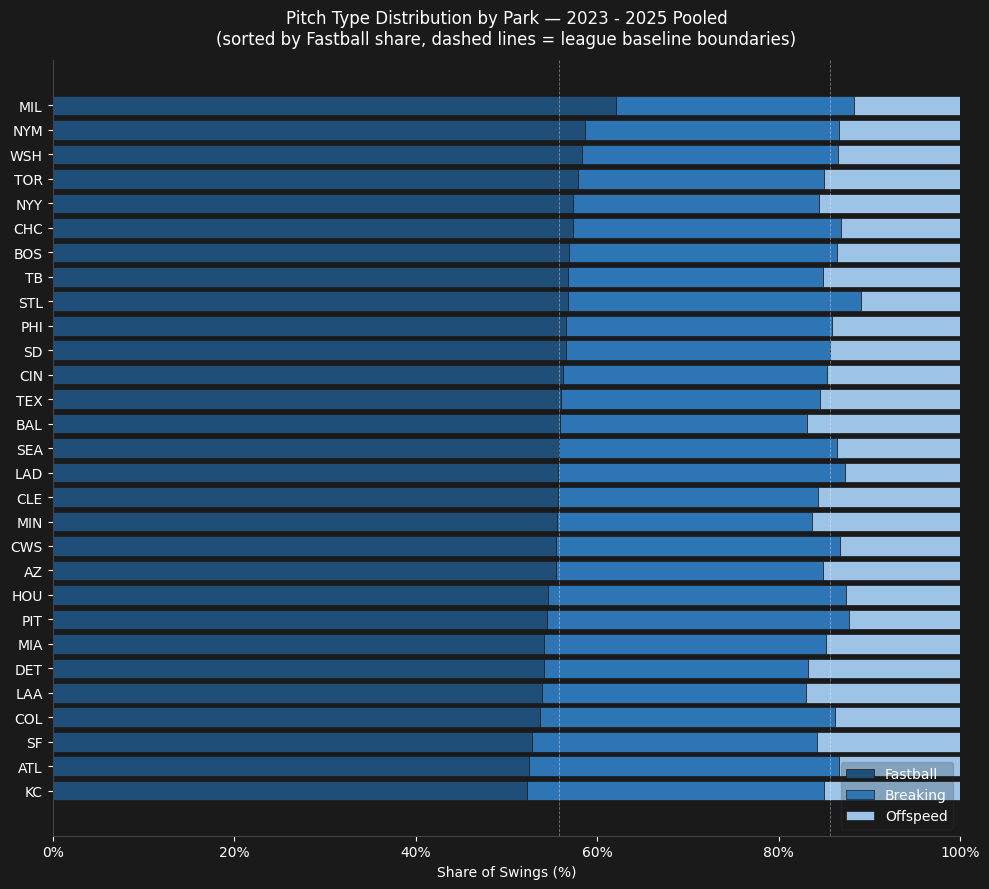

In [7]:
# Sort parks by fastball proportion descending — most fastball-heavy parks on top
park_props_sorted = park_props.sort_values("Fastball", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

left = np.zeros(len(park_props_sorted))
for cat in ["Fastball", "Breaking", "Offspeed"]:
    values = park_props_sorted[cat].values * 100
    bars = ax.barh(
        park_props_sorted.index,
        values,
        left=left,
        color=COLORS[cat],
        label=cat,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    left += values

# Lines that reference the league baselines
for i, cat in enumerate(["Fastball", "Breaking", "Offspeed"]):
    cumulative = league_baseline.loc[["Fastball", "Breaking", "Offspeed"][:i+1], "pct"].sum()
    ax.axvline(cumulative, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

ax.set_xlabel("Share of Swings (%)", color="white")
ax.set_title("Pitch Type Distribution by Park — 2023 - 2025 Pooled\n(sorted by Fastball share, dashed lines = league baseline boundaries)", 
             fontsize=12, pad=12, color="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

ax.legend(
    loc="lower right",
    framealpha=0.2,
    labelcolor="white",
    facecolor="#1a1a1a",
    edgecolor="#444444",
)

plt.tight_layout()
plt.show()

___
## 4) Deviation from Baseline

In [8]:
# subtracting league baseline from each park's proportions
# positive = park throws that type more than league average, negative indicates less
baseline_props = league_baseline["proportion"]

park_deviations = park_props.subtract(baseline_props, axis=1) * 100  # expressed in percentage points

print("Deviation from League Baseline (percentage points)\n")
print(park_deviations.sort_values("Fastball", ascending=False).round(2).to_string())

Deviation from League Baseline (percentage points)

pitch_category  Fastball  Breaking  Offspeed
home_team                                   
MIL                 6.26     -3.62     -2.63
NYM                 2.76     -1.77     -0.98
WSH                 2.43     -1.57     -0.86
TOR                 2.08     -2.73      0.65
NYY                 1.51     -2.79      1.28
CHC                 1.50     -0.29     -1.21
BOS                 1.03     -0.33     -0.70
TB                  0.97     -1.74      0.78
STL                 0.90      2.46     -3.36
PHI                 0.77     -0.53     -0.24
SD                  0.68     -0.71      0.04
CIN                 0.34     -0.72      0.38
TEX                 0.20     -1.37      1.17
BAL                 0.11     -2.65      2.55
SEA                -0.06      0.75     -0.70
LAD                -0.17      1.83     -1.66
CLE                -0.18     -1.17      1.36
MIN                -0.28     -1.68      1.96
CWS                -0.33      1.39     -1.06
AZ 

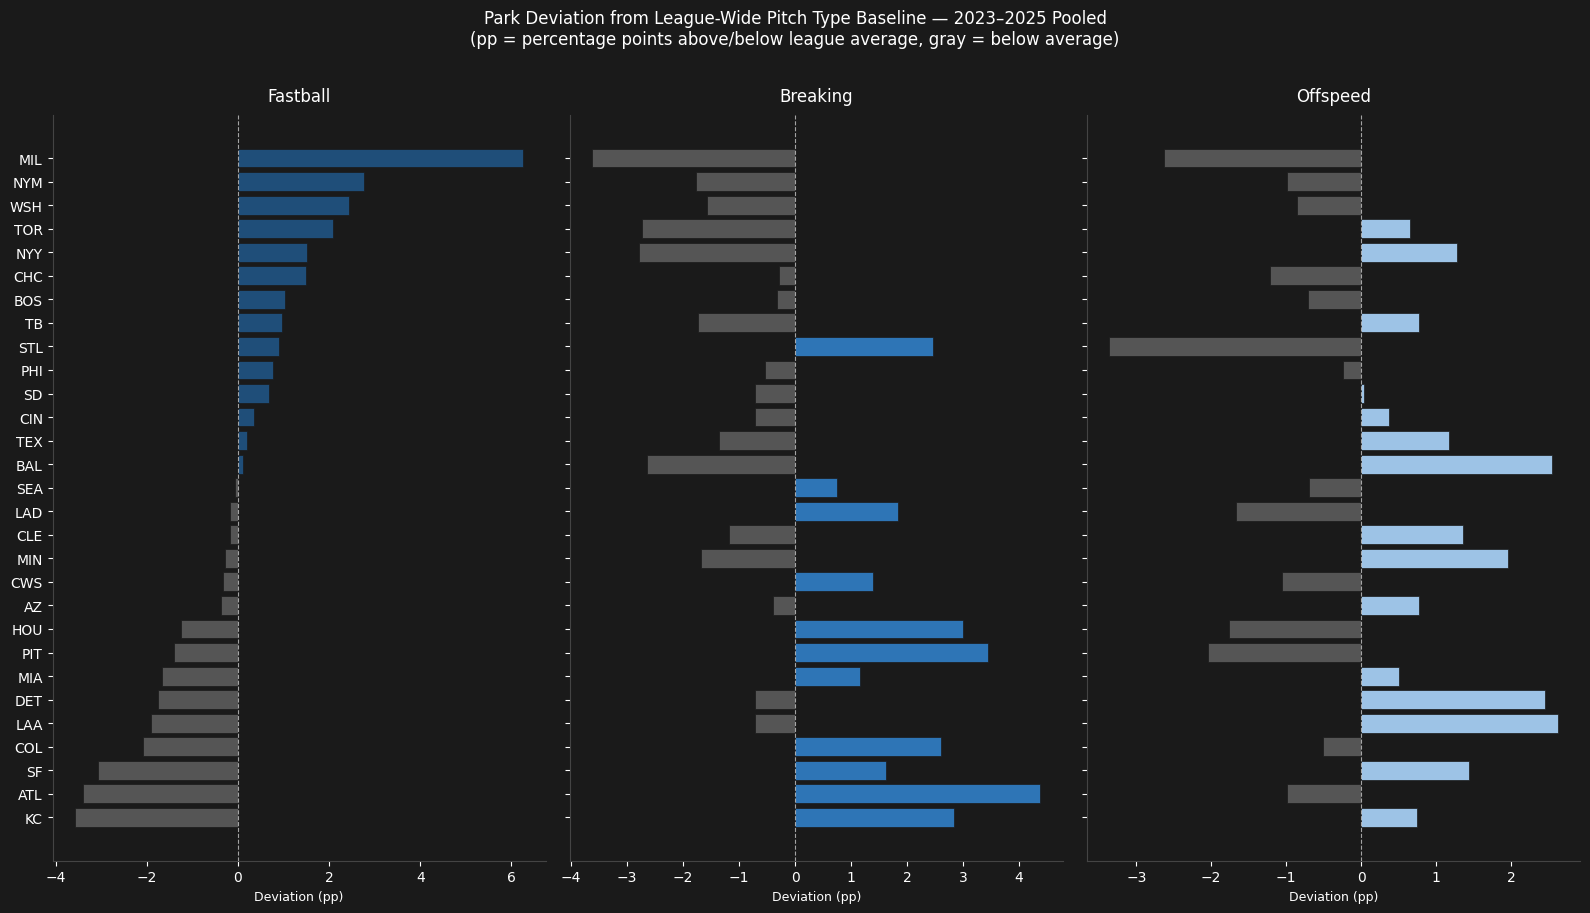

In [9]:
# Sort by fastball deviation — puts Milwaukee at top and confirms visual from Section 3
dev_sorted = park_deviations.sort_values("Fastball", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

for ax, cat in zip(axes, ["Fastball", "Breaking", "Offspeed"]):
    values = dev_sorted[cat]
    colors = [COLORS[cat] if v > 0 else "#555555" for v in values]
    
    ax.barh(
        dev_sorted.index,
        values,
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(cat, color="white", fontsize=12, pad=10)
    ax.set_xlabel("Deviation (pp)", color="white", fontsize=9)
    ax.tick_params(colors="white")
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Park Deviation from League-Wide Pitch Type Baseline — 2023–2025 Pooled\n(pp = percentage points above/below league average, gray = below average)",
    color="white", fontsize=12, y=1.01
)

plt.tight_layout()
plt.show()

___
## 5) Statistical Significance

Chi-Square GOF test for each park against league distribution

In [10]:
from scipy.stats import chisquare

# expected proportions from league baseline
expected_props = baseline_props[["Fastball", "Breaking", "Offspeed"]].values

results = []
for park in park_counts.index:
    observed = park_counts.loc[park, ["Fastball", "Breaking", "Offspeed"]].values
    n = observed.sum()
    expected = expected_props * n  # scale to park sample size
    
    chi2, p = chisquare(f_obs=observed, f_exp=expected)
    
    results.append({
        "park":      park,
        "n":         n,
        "chi2":      round(chi2, 3),
        "p_value":   round(p, 4),
        "significant": p < 0.05,
    })

chi2_results = (
    pd.DataFrame(results)
    .set_index("park")
    .sort_values("chi2", ascending=False)
)

print("Chi-Square Goodness-of-Fit — Park vs. League Baseline\n")
print(chi2_results.to_string())

Chi-Square Goodness-of-Fit — Park vs. League Baseline

         n    chi2  p_value  significant
park                                    
MIL   5903  95.994   0.0000         True
STL   5992  60.209   0.0000         True
ATL   5927  54.481   0.0000         True
PIT   6000  43.525   0.0000         True
BAL   5957  41.080   0.0000         True
LAA   5973  33.532   0.0000         True
HOU   5978  32.687   0.0000         True
KC    5948  31.919   0.0000         True
DET   5965  29.443   0.0000         True
NYY   5999  25.022   0.0000         True
SF    5966  23.890   0.0000         True
MIN   6000  21.875   0.0000         True
TOR   5999  21.360   0.0000         True
COL   5994  19.368   0.0001         True
NYM   5998  18.547   0.0001         True
LAD   5988  18.340   0.0001         True
WSH   5948  14.230   0.0008         True
CLE   5970  10.444   0.0054         True
TB    5981   9.602   0.0082         True
TEX   5990   9.521   0.0086         True
CWS   5964   8.649   0.0132         True
CH

In [11]:
sig_count = chi2_results["significant"].sum()
print(f"{sig_count} of 29 parks deviate significantly from league baseline (p < 0.05)")
print(f"{29 - sig_count} parks are statistically indistinguishable from league average")

23 of 29 parks deviate significantly from league baseline (p < 0.05)
6 parks are statistically indistinguishable from league average


**With 23 of the 29 parks having significant deviations from league-wide pitch type baseline, this confirms that ballpark environment is associated with meaningful differences in pitch type composition across the sample.**
<br>
The 6 parks that do NOT have significant differences to league-wide averages are:
- BOS (Fenway Park)
- SEA (T-Mobile Park)
- AZ  (Chase Field)
- CIN (Great American Ballpark)
- SD  (Petco Park)
- PHI (Citizens Bank Park)
<br>

One big thing to note here, is the Chi-square magnitude varying substantially across 'significant' parks.  Milwaukee with a chi2 value of 95.994 is even an outlier among defined deviating parks.
<br>

With ~5,970 swings per park, statistical power is high enough for minor deviations to clear a `p < 0.05`. Chi-square magnitude and Section 4 deviation sizes really separate meaningful park tendencies from noise.
<br>

St. Louis ranks second in chi2 (60.21), but does not standout visually in the Section 3 stacked bar.  This suggests the deviation isn't fastball driven. (Section 6 may help clear this up)

___
## 6) Individual Pitch Code Breakdown (Level 2)

Parks selected for Level 2 based on chi2 magnitude and unexplained (so far) deviations

In [12]:
FOCUS_PARKS = ["MIL", "STL", "ATL", "PIT", "BAL"]

# filter to focus parks only
df_focus = df[df["home_team"].isin(FOCUS_PARKS)]

# compute pitch code proportions within each park
pitch_code_counts = (
    df_focus.groupby(["home_team", "pitch_type"])
    .size()
    .unstack(fill_value=0)
)

pitch_code_props = pitch_code_counts.div(pitch_code_counts.sum(axis=1), axis=0) * 100

# attach pitch category labels for grouping
pitch_category_map = (
    df[["pitch_type", "pitch_category"]]
    .drop_duplicates()
    .set_index("pitch_type")["pitch_category"]
    .to_dict()
)

print("Level 2 Pitch Code Proportions — Focus Parks (% of park swings)\n")
print(pitch_code_props.round(2).to_string())

Level 2 Pitch Code Proportions — Focus Parks (% of park swings)

pitch_type     CH    CS    CU    EP    FA     FC     FF    FO    FS    KC    SC     SI     SL    ST    SV
home_team                                                                                                
ATL          9.74  0.02  7.96  0.22  0.08   7.47  31.72  0.00  3.32  1.40  0.03  13.18  20.31  4.27  0.27
BAL         12.89  0.02  7.13  0.05  0.05  10.76  31.53  0.00  3.91  1.21  0.00  13.61  11.97  6.03  0.84
MIL          9.42  0.14  5.37  0.05  0.19  11.57  31.70  0.02  2.07  1.27  0.00  18.65  13.48  5.76  0.32
PIT          8.63  0.08  7.02  0.03  0.00   7.98  32.00  0.05  3.48  1.17  0.00  14.45  17.87  6.82  0.42
STL          9.08  0.05  7.24  0.00  0.15   7.54  28.77  0.07  1.77  1.18  0.00  20.28  15.82  7.83  0.22


In [13]:
# need league-level pitch code proportions to compute deviations/comparisons

league_code_props = (
    df["pitch_type"].value_counts(normalize=True) * 100
).rename("league_pct")

print("League-Wide Pitch Code Baseline\n")
print(league_code_props.round(2).to_string())

League-Wide Pitch Code Baseline

pitch_type
FF    32.48
SL    15.37
SI    15.02
CH    10.93
FC     8.22
ST     6.59
CU     5.74
FS     3.19
KC     1.71
SV     0.42
FA     0.13
EP     0.10
FO     0.08
CS     0.02
SC     0.01


In [14]:
# deviation from league baseline for each focus park
code_deviations = pitch_code_props.subtract(league_code_props, axis=1).dropna(axis=1, how="all")

print("Level 2 Deviations from League Baseline (percentage points)\n")
print(code_deviations.round(2).to_string())

Level 2 Deviations from League Baseline (percentage points)

pitch_type    CH    CS    CU    EP    FA    FC    FF    FO    FS    KC    SC    SI    SL    ST    SV
home_team                                                                                           
ATL        -1.19 -0.01  2.22  0.12 -0.04 -0.74 -0.76 -0.08  0.14 -0.31  0.03 -1.85  4.94 -2.33 -0.15
BAL         1.97 -0.01  1.39 -0.05 -0.08  2.54 -0.95 -0.08  0.72 -0.50 -0.01 -1.41 -3.40 -0.57  0.42
MIL        -1.51  0.11 -0.37 -0.05  0.06  3.35 -0.78 -0.06 -1.12 -0.44 -0.01  3.63 -1.89 -0.83 -0.09
PIT        -2.29  0.06  1.27 -0.07 -0.13 -0.23 -0.48 -0.03  0.30 -0.54 -0.01 -0.57  2.50  0.22  0.00
STL        -1.85  0.03  1.50 -0.10  0.02 -0.67 -3.71 -0.01 -1.42 -0.52 -0.01  5.25  0.45  1.23 -0.20


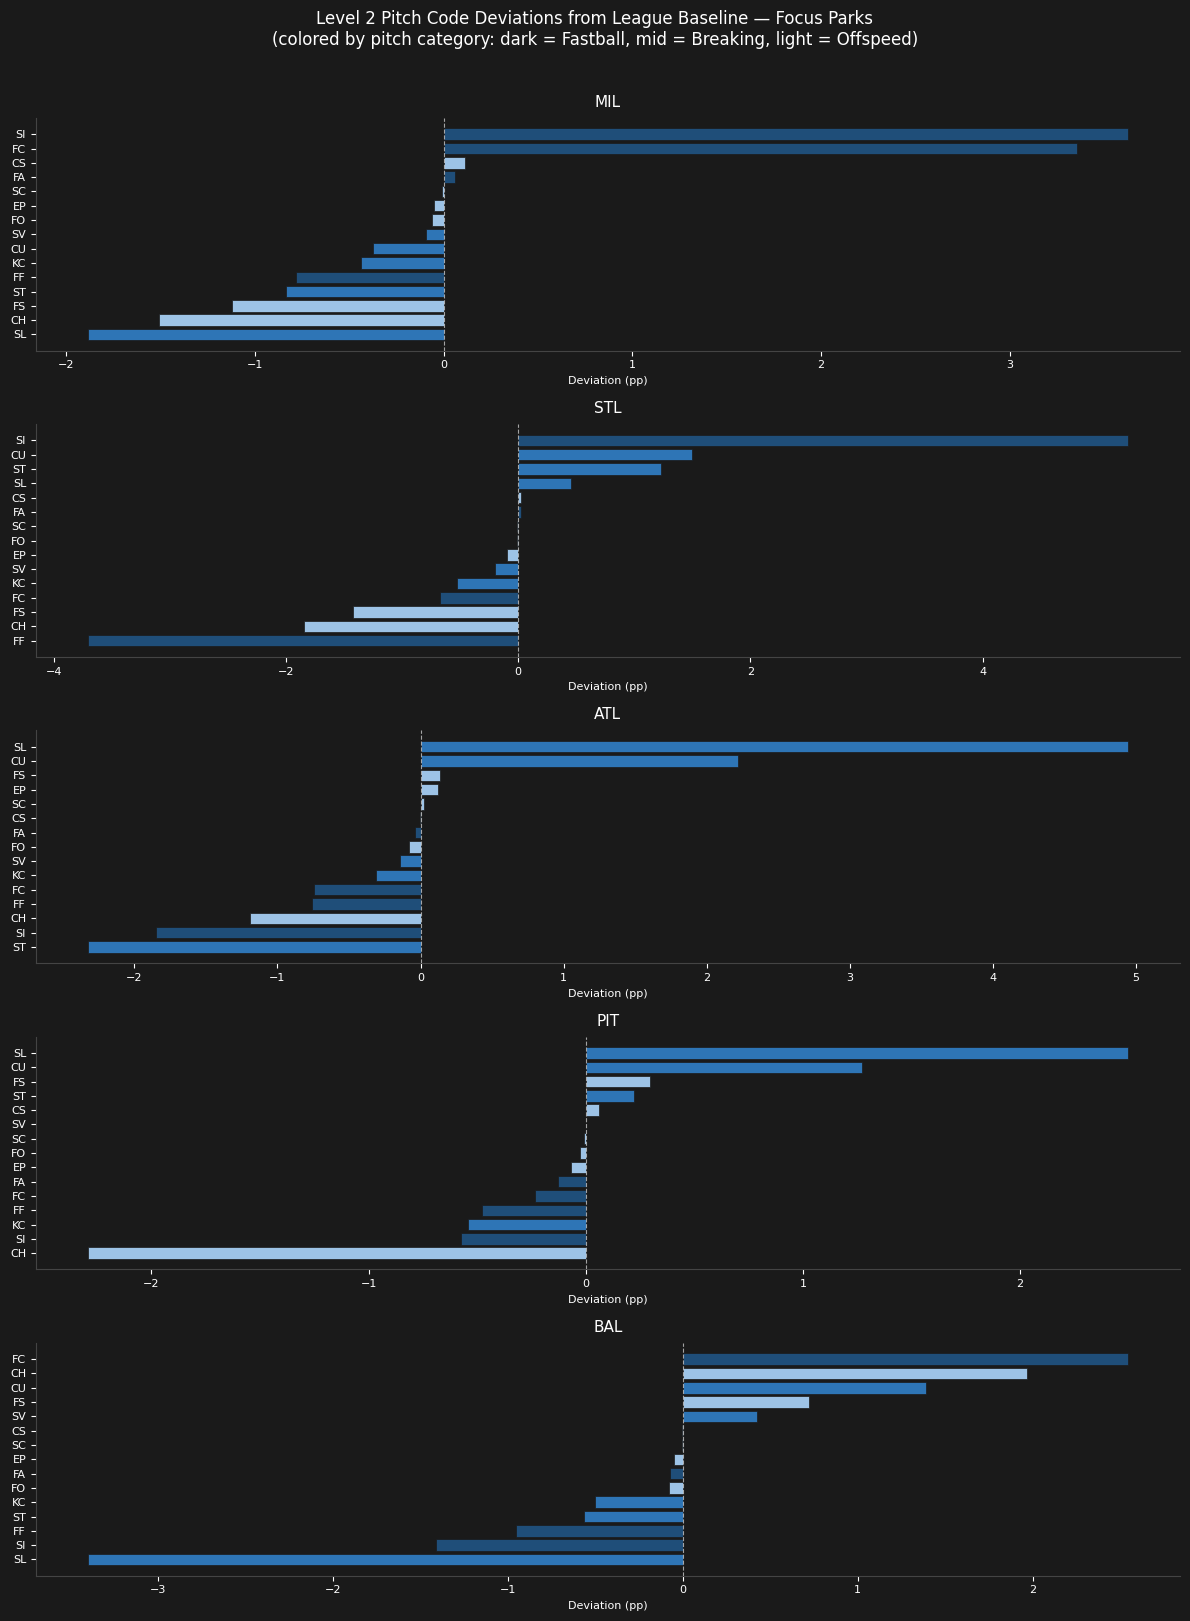

In [15]:
fig, axes = plt.subplots(len(FOCUS_PARKS), 1, figsize=(12, 16), sharex=False)

for ax, park in zip(axes, FOCUS_PARKS):
    devs = code_deviations.loc[park].dropna().sort_values()
    colors = [COLORS.get(pitch_category_map.get(pt, "Offspeed"), "#9DC3E6") for pt in devs.index]
    
    ax.barh(
        devs.index,
        devs.values,
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(park, color="white", fontsize=11, pad=8)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")
    ax.set_xlabel("Deviation (pp)", color="white", fontsize=8)

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Level 2 Pitch Code Deviations from League Baseline — Focus Parks\n(colored by pitch category: dark = Fastball, mid = Breaking, light = Offspeed)",
    color="white", fontsize=12, y=1.01
)

plt.tight_layout()
plt.show()

Level 2 reveals distinct pitching identities across all five focus parks that are invisible at the Level 1 category level:

| Park | Key Signal(s) | Story |
|------|-----------|-------|
| MIL | SI +3.63, FC +3.35 | Broad fastball portfolio — no single dominant pitch, organizational velocity identity |
| STL | SI heavily positive, FF -4.00 | FF → SI substitution — deliberate ground ball philosophy at Busch Stadium |
| ATL | SL +4.94 | Slider dominance — Truist Park pitchers attacking with breaking ball above all else |
| PIT | SL +2.50, CH -2.50 | CH → SL substitution — breaking ball preferred over offspeed at PNC |
| BAL | FC +2.50, SL -3.50 | SL → FC substitution — pitchers staying hard with late movement rather than spinning |

The STL and BAL findings are particularly notable — both parks show active *substitution patterns* rather than simple volume increases, suggesting environmental or organizational factors are shaping pitch selection at the recipe level, not just the category level.

___
## 7) Handedness Cut (Metadata Check)

Intentionally light section, metadata check, not a primary finding.  Goal is to simply confirm that the deviations found in Sections 4-6 aren't attributed to one park happening to face a lopsided mix of left/right batters or pitchers w/in the same sample.

In [16]:
# confirm overall sample balance before park-level check
stand_balance = df["stand"].value_counts(normalize=True) * 100
p_throws_balance = df["p_throws"].value_counts(normalize=True) * 100

print("League-Wide Batter Handedness (stand)\n")
print(stand_balance.round(2).to_string())
print("\nLeague-Wide Pitcher Handedness (p_throws)\n")
print(p_throws_balance.round(2).to_string())

League-Wide Batter Handedness (stand)

stand
R    57.49
L    42.51

League-Wide Pitcher Handedness (p_throws)

p_throws
R    73.43
L    26.57


In [17]:
# compute L/R proportions per park for both stand and p_throws
stand_by_park = (
    df.groupby(["home_team", "stand"])
    .size()
    .unstack(fill_value=0)
    .assign(n=lambda x: x.sum(axis=1))
)
stand_by_park["L_pct"] = stand_by_park["L"] / stand_by_park["n"] * 100
stand_by_park["R_pct"] = stand_by_park["R"] / stand_by_park["n"] * 100

p_throws_by_park = (
    df.groupby(["home_team", "p_throws"])
    .size()
    .unstack(fill_value=0)
    .assign(n=lambda x: x.sum(axis=1))
)
p_throws_by_park["L_pct"] = p_throws_by_park["L"] / p_throws_by_park["n"] * 100
p_throws_by_park["R_pct"] = p_throws_by_park["R"] / p_throws_by_park["n"] * 100

print("Batter Handedness by Park (% Left)\n")
print(stand_by_park[["n", "L_pct", "R_pct"]].sort_values("L_pct", ascending=False).round(2).to_string())
print("\nPitcher Handedness by Park (% Left)\n")
print(p_throws_by_park[["n", "L_pct", "R_pct"]].sort_values("L_pct", ascending=False).round(2).to_string())

Batter Handedness by Park (% Left)

stand         n  L_pct  R_pct
home_team                    
CLE        5970  53.87  46.13
BAL        5957  48.63  51.37
BOS        5955  47.51  52.49
WSH        5948  46.87  53.13
AZ         5996  45.61  54.39
SEA        5944  45.59  54.41
LAD        5988  44.92  55.08
MIN        6000  44.88  55.12
NYM        5998  43.95  56.05
ATL        5927  43.21  56.79
SD         5948  43.21  56.79
NYY        5999  43.21  56.79
KC         5948  43.19  56.81
MIL        5903  42.37  57.63
SF         5966  42.17  57.83
DET        5965  42.03  57.97
CHC        5910  41.59  58.41
PHI        5993  41.47  58.53
TB         5981  41.45  58.55
TEX        5990  41.42  58.58
CWS        5964  40.44  59.56
STL        5992  40.19  59.81
MIA        5998  40.16  59.84
PIT        6000  39.83  60.17
TOR        5999  39.71  60.29
CIN        5953  38.05  61.95
COL        5994  36.85  63.15
LAA        5973  36.00  64.00
HOU        5978  34.59  65.41

Pitcher Handedness by Park (% Lef

In [18]:
# flag parks sitting more than 3pp outside league average on either split
stand_mean = stand_by_park["L_pct"].mean()
p_throws_mean = p_throws_by_park["L_pct"].mean()

stand_outliers = stand_by_park[
    (stand_by_park["L_pct"] - stand_mean).abs() > 3
][["n", "L_pct"]].copy()
stand_outliers["deviation"] = (stand_outliers["L_pct"] - stand_mean).round(2)

p_throws_outliers = p_throws_by_park[
    (p_throws_by_park["L_pct"] - p_throws_mean).abs() > 3
][["n", "L_pct"]].copy()
p_throws_outliers["deviation"] = (p_throws_outliers["L_pct"] - p_throws_mean).round(2)

print(f"Batter handedness league mean: {stand_mean:.2f}% left")
print(f"Parks flagged (>3pp deviation): {len(stand_outliers)}")
print(stand_outliers.sort_values("deviation").to_string() if len(stand_outliers) > 0 else "None")

print(f"\nPitcher handedness league mean: {p_throws_mean:.2f}% left")
print(f"Parks flagged (>3pp deviation): {len(p_throws_outliers)}")
print(p_throws_outliers.sort_values("deviation").to_string() if len(p_throws_outliers) > 0 else "None")

Batter handedness league mean: 42.52% left
Parks flagged (>3pp deviation): 10
stand         n      L_pct  deviation
home_team                            
HOU        5978  34.593510      -7.92
LAA        5973  35.995312      -6.52
COL        5994  36.853520      -5.66
CIN        5953  38.048043      -4.47
SEA        5944  45.592194       3.08
AZ         5996  45.613742       3.10
WSH        5948  46.872898       4.36
BOS        5955  47.506297       4.99
BAL        5957  48.631862       6.12
CLE        5970  53.869347      11.35

Pitcher handedness league mean: 26.57% left
Parks flagged (>3pp deviation): 7
p_throws      n      L_pct  deviation
home_team                            
MIN        6000  16.733333      -9.83
SEA        5944  17.816285      -8.75
TOR        5999  21.020170      -5.55
TB         5981  22.069888      -4.50
LAA        5973  32.060941       5.49
PHI        5993  34.390122       7.82
WSH        5948  36.735037      10.17


**Handedness composition is reasonably balanced across the sample, with no evidence that the pitch type deviations identified in Sections 4–6 are artifacts of skewed batter or pitcher handedness distributions.**

10 parks were flagged on batter handedness (>3pp from league mean of 42.52% left) and 7 on pitcher handedness (>3pp from league mean of 26.57% left). Only two parks appear on both lists:

- **WSH** — elevated lefty batters (+4.36pp) and the most lefty-pitcher environment in the sample (+10.17pp)
- **SEA** — slightly elevated lefty batters (+3.08pp) but well below average on lefty pitchers (-8.75pp)

**CLE** is the most extreme batter handedness outlier at +11.35pp — the most left-handed batter environment in the sample by a significant margin.

Critically, none of these five Level 2 focus parks (MIL, STL, ATL, PIT) appear in either flagged list. **BAL is the one exception** — flagged at +6.12pp on batter handedness — meaning the SL → FC substitution finding at Camden Yards could carry a handedness component worth revisiting in a future modeling layer.

Handedness is retained as metadata for all observations and explicitly flagged as a covariate for future analysis.

___
## 8) Observations & Forward Look

Notebook 04 confirms ballpark environment being meaningfully associated with pitch type composition with 23 of 29 parks deviating significantly from league-wide baseline, and the Level 2 breakdown reveals that the most interesting signal is **recipe** rather than volume.

**Milwaukee is the standout finding of this notebook.** American Family Field produces the largest Level 1 fastball deviation in the sample at +6pp above league average — but Level 2 tells the real story. That lean is driven by an unusually high sinker (SI) and cutter (FC) presence, while slider usage sits well below league average. This is not a park that simply throws hard, it's a park that throws *heavy and late*, prioritizing pitch types known to generate weak contact over spin-based / swing-and-miss pitches.

**Busch Stadium's sinker concentration is equally striking.** STL's chi2 of 60.21 is second only to Milwaukee, and Level 2 reveals a near-complete FF → SI substitution pattern. Four-seam fastballs are actively being replaced by sinkers, alluding to a ground ball philosophy.

**Truist Park leads the sample in slider presence** at +4.94pp above league average — the most spin-heavy attack profile among focus parks, and a stark contrast to Milwaukee's ground ball identity next door in the NL.

The substitution patterns across focus parks are the most analytically compelling Layer 1 finding:

| Park | Substitution |
|------|-------------|
| STL | FF → SI |
| PIT | CH → SL |
| BAL | SL → FC |

These are not parks throwing more of everything — they are parks with distinct pitching approaches.

**Six parks show no detectable pitch type personality** — BOS, SEA, AZ, CIN, SD, and PHI are statistically indistinguishable from league average. Whether that reflects environmental neutrality or organizational tendency is a question this dataset cannot answer alone.

___
*Notebook 05 will examine whether these pitch mix differences translate to different swing outcomes — do Milwaukee's sinkers and cutters produce different whiff and foul rates than league average? Notebook 06 then asks the contact quality question: when batters do make contact in these environments, is the quality meaningfully different?*